# 05 — Splitting, Visualization & Summary Report

> **Goal:** Optionally re-split the preprocessed dataset with a stratified 70/20/10 split, produce comprehensive visualization plots, and generate a final quality + recommendations report.

**What this notebook does:**
1. Reads `dataset_preprocessed/` (NB04 output)
2. Optionally re-splits training data (stratified by primary class per image)
3. Writes the final `dataset/` folder with correct `data.yaml`
4. Generates all required visualizations
5. Prints the Summary Report

**Note:** If you are satisfied with the existing train/valid/test split, set `RESPLIT = False` and this notebook will just visualize and report.

**Output:** `dataset/` — final, ready-for-YOLOv8 dataset  
**Plots:** `logs/05_*.png`

In [1]:
import subprocess, sys
for pkg in [('cv2','opencv-python'),('yaml','pyyaml'),('tqdm','tqdm'),
            ('sklearn','scikit-learn'),('seaborn','seaborn'),
            ('numpy','numpy'),('matplotlib','matplotlib')]:
    try:
        __import__(pkg[0])
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg[1]])
print('Packages OK.')

Packages OK.


In [2]:
import os
import cv2
import json
import yaml
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib    import Path
from datetime   import datetime
from collections import Counter
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

random.seed(42)
np.random.seed(42)
print('Imports complete.')

Imports complete.


## Configuration

In [3]:
# ── Source: prefer preprocessed, fall back to cleaned ────────
SRC_CANDIDATES = [
    Path('dataset_preprocessed'),
    Path('dataset_cleaned'),
    Path('DATA_AFTER MERGED'),
]
SRC_DIR = next((p for p in SRC_CANDIDATES if p.exists()), None)
assert SRC_DIR, 'No input dataset found. Run NB04 first.'
print(f'Source dataset : {SRC_DIR.resolve()}')

# ── Final output ─────────────────────────────────────────────
OUT_DIR   = Path('dataset')   # YOLOv8-ready final folder
LOG_DIR   = Path('logs')
LOG_DIR.mkdir(exist_ok=True)
TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')

# ── Re-split settings ────────────────────────────────────────
#  Set RESPLIT = True to re-create splits from all available data.
#  Set RESPLIT = False to keep the existing train/valid/test split as-is.
RESPLIT      = False
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.20
TEST_RATIO   = 0.10

# ── Class config ─────────────────────────────────────────────
yaml_candidates = [SRC_DIR / 'data.yaml', Path('DATA_AFTER MERGED') / 'data.yaml']
yaml_path = next((p for p in yaml_candidates if p.exists()), None)
assert yaml_path, 'data.yaml not found'
with open(yaml_path) as f:
    data_yaml = yaml.safe_load(f)
CLASS_NAMES = data_yaml['names']
NUM_CLASSES = len(CLASS_NAMES)

print(f'Output dir     : {OUT_DIR.resolve()}')
print(f'Re-split       : {RESPLIT}')
print(f'Classes ({NUM_CLASSES})   : {CLASS_NAMES}')

Source dataset : C:\Users\shaho\OneDrive\Desktop\grad\dataset_preprocessed
Output dir     : C:\Users\shaho\OneDrive\Desktop\grad\dataset
Re-split       : False
Classes (6)   : ['Customer-Bagpack', 'Product', 'Product-Picked', 'Shopping-Cart', 'normal', 'theft']


## Helper Functions

In [4]:
IMG_EXTS = ('*.jpg','*.jpeg','*.png','*.JPG','*.JPEG','*.PNG','*.bmp','*.BMP')


def collect_pairs(img_dir: Path, lbl_dir: Path) -> list:
    """Return sorted list of (img_path, lbl_path) where both files exist."""
    pairs = []
    for ext in IMG_EXTS:
        for ip in img_dir.glob(ext):
            lp = lbl_dir / f'{ip.stem}.txt'
            if lp.exists():
                pairs.append((ip, lp))
    return sorted(set(pairs))


def primary_class(lbl_path: Path) -> int:
    """
    Return the most frequent class in a label file.
    Used as the stratification key for train/val/test splitting.
    Returns -1 for empty / missing labels.
    """
    if not lbl_path.exists() or lbl_path.stat().st_size == 0:
        return -1
    cnt = Counter()
    for line in lbl_path.read_text(encoding='utf-8', errors='replace').splitlines():
        parts = line.strip().split()
        if len(parts) == 5:
            try:
                cnt[int(float(parts[0]))] += 1
            except ValueError:
                pass
    return cnt.most_common(1)[0][0] if cnt else -1


def copy_pair(img_src: Path, lbl_src: Path,
              img_dst_dir: Path, lbl_dst_dir: Path):
    shutil.copy2(img_src, img_dst_dir / img_src.name)
    shutil.copy2(lbl_src, lbl_dst_dir / f'{img_src.stem}.txt')


def scan_split(split_name: str, img_dir: Path, lbl_dir: Path) -> dict:
    """
    Scan a split and return class counts + bbox stats.
    """
    pairs = collect_pairs(img_dir, lbl_dir)
    class_counts  = Counter()
    bbox_widths   = []
    bbox_heights  = []
    img_widths    = []
    img_heights   = []
    ann_counts    = []

    for img_path, lbl_path in tqdm(pairs, desc=f'  Scanning {split_name}', unit='img'):
        # Image dims
        img = cv2.imread(str(img_path))
        if img is not None:
            img_heights.append(img.shape[0])
            img_widths.append(img.shape[1])

        # Labels
        n_ann = 0
        if lbl_path.stat().st_size > 0:
            for line in lbl_path.read_text(encoding='utf-8', errors='replace').splitlines():
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                try:
                    cls_id         = int(float(parts[0]))
                    bw, bh         = float(parts[3]), float(parts[4])
                except ValueError:
                    continue
                if 0 <= cls_id < NUM_CLASSES and bw > 0 and bh > 0:
                    class_counts[cls_id] += 1
                    bbox_widths.append(bw)
                    bbox_heights.append(bh)
                    n_ann += 1
        ann_counts.append(n_ann)

    return {
        'n_images':     len(pairs),
        'class_counts': dict(class_counts),
        'bbox_widths':  bbox_widths,
        'bbox_heights': bbox_heights,
        'img_widths':   img_widths,
        'img_heights':  img_heights,
        'ann_counts':   ann_counts,
    }


print('Functions defined.')

Functions defined.


## Step 1 — Build Final Dataset (re-split or copy-as-is)

In [6]:
from tqdm import tqdm
FINAL_SPLITS = {'train': 'train', 'val': 'valid', 'test': 'test'}

# Create output dirs
for split in FINAL_SPLITS:
    for sub in ('images', 'labels'):
        (OUT_DIR / split / sub).mkdir(parents=True, exist_ok=True)

if RESPLIT:
    print('Re-splitting all data...')

    # Gather all pairs from all existing splits
    all_pairs = []
    for sp in ['train', 'valid', 'test']:
        img_dir = SRC_DIR / sp / 'images'
        lbl_dir = SRC_DIR / sp / 'labels'
        if img_dir.exists():
            all_pairs.extend(collect_pairs(img_dir, lbl_dir))

    print(f'Total pairs available: {len(all_pairs):,}')

    # Stratification label = primary class
    strat_labels = [primary_class(lp) for _, lp in
                    tqdm(all_pairs, desc='Computing strat labels')]

    # Remove -1 (empty labels) from stratification
    valid_idx = [i for i, s in enumerate(strat_labels) if s >= 0]
    pairs_s   = [all_pairs[i] for i in valid_idx]
    labels_s  = [strat_labels[i] for i in valid_idx]

    # Ensure every class has at least 2 members (else can't stratify)
    cnt_s = Counter(labels_s)
    rare  = [c for c, n in cnt_s.items() if n < 3]
    if rare:
        print(f'Classes with <3 samples (moved to train): {rare}')
        rare_idx = [i for i, l in enumerate(labels_s) if l in rare]
        keep_idx = [i for i, l in enumerate(labels_s) if l not in rare]
        rare_pairs  = [pairs_s[i] for i in rare_idx]
        pairs_s     = [pairs_s[i] for i in keep_idx]
        labels_s    = [labels_s[i] for i in keep_idx]
    else:
        rare_pairs = []

    # 70 / 30 split, then 30 → 20/10
    train_p, temp_p, train_l, temp_l = train_test_split(
        pairs_s, labels_s,
        test_size=1.0 - TRAIN_RATIO,
        stratify=labels_s,
        random_state=42
    )
    rel_val = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
    val_p, test_p, _, _ = train_test_split(
        temp_p, temp_l,
        test_size=1.0 - rel_val,
        stratify=temp_l,
        random_state=42
    )

    # Add rare pairs to train
    train_p = train_p + rare_pairs

    split_pairs = {'train': train_p, 'val': val_p, 'test': test_p}
    print(f'  train={len(train_p):,}  val={len(val_p):,}  test={len(test_p):,}')

    # Copy to output
    for split_name, pairs in split_pairs.items():
        img_out = OUT_DIR / split_name / 'images'
        lbl_out = OUT_DIR / split_name / 'labels'
        for ip, lp in tqdm(pairs, desc=f'  Copying {split_name}'):
            copy_pair(ip, lp, img_out, lbl_out)

else:
    # Copy existing splits as-is
    print('Copying existing splits to final dataset folder...')
    src_split_map = {'train': 'train', 'val': 'valid', 'test': 'test'}
    for out_split, src_split in src_split_map.items():
        img_src = SRC_DIR / src_split / 'images'
        lbl_src = SRC_DIR / src_split / 'labels'
        img_out = OUT_DIR / out_split / 'images'
        lbl_out = OUT_DIR / out_split / 'labels'
        if not img_src.exists():
            print(f'  WARNING: {img_src} not found — skipping.')
            continue
        pairs = collect_pairs(img_src, lbl_src)
        for ip, lp in tqdm(pairs, desc=f'  Copying {out_split}', unit='pair'):
            copy_pair(ip, lp, img_out, lbl_out)
        print(f'  [{out_split}] {len(pairs):,} pairs copied')

print('\nFinal dataset assembled.')

Copying existing splits to final dataset folder...


  Copying train: 100%|██████████| 24583/24583 [01:43<00:00, 238.03pair/s]


  [train] 24,583 pairs copied


  Copying val: 100%|██████████| 1526/1526 [00:06<00:00, 235.88pair/s]


  [val] 1,526 pairs copied


  Copying test: 100%|██████████| 740/740 [00:02<00:00, 261.95pair/s]

  [test] 740 pairs copied

Final dataset assembled.


## Write Final data.yaml

In [7]:
final_yaml = {
    'path':  str(OUT_DIR.resolve()),
    'train': 'train/images',
    'val':   'val/images',
    'test':  'test/images',
    'nc':    NUM_CLASSES,
    'names': CLASS_NAMES,
}
yaml_out = OUT_DIR / 'data.yaml'
with open(yaml_out, 'w') as f:
    yaml.dump(final_yaml, f, default_flow_style=False, allow_unicode=True)

print('data.yaml:')
print(yaml_out.read_text())

data.yaml:
names:
- Customer-Bagpack
- Product
- Product-Picked
- Shopping-Cart
- normal
- theft
nc: 6
path: C:\Users\shaho\OneDrive\Desktop\grad\dataset
test: test/images
train: train/images
val: val/images



## Scan Final Dataset for Visualizations

In [8]:
final_stats = {}
for split in ['train', 'val', 'test']:
    img_dir = OUT_DIR / split / 'images'
    lbl_dir = OUT_DIR / split / 'labels'
    if img_dir.exists():
        final_stats[split] = scan_split(split, img_dir, lbl_dir)

print('\nFinal dataset counts:')
for split, st in final_stats.items():
    print(f'  [{split}] {st["n_images"]:,} images')

  Scanning test: 100%|██████████| 740/740 [00:02<00:00, 299.46img/s]


Final dataset counts:
  [train] 24,583 images
  [val] 1,526 images
  [test] 740 images


## Visualization 1 — Class Distribution by Split

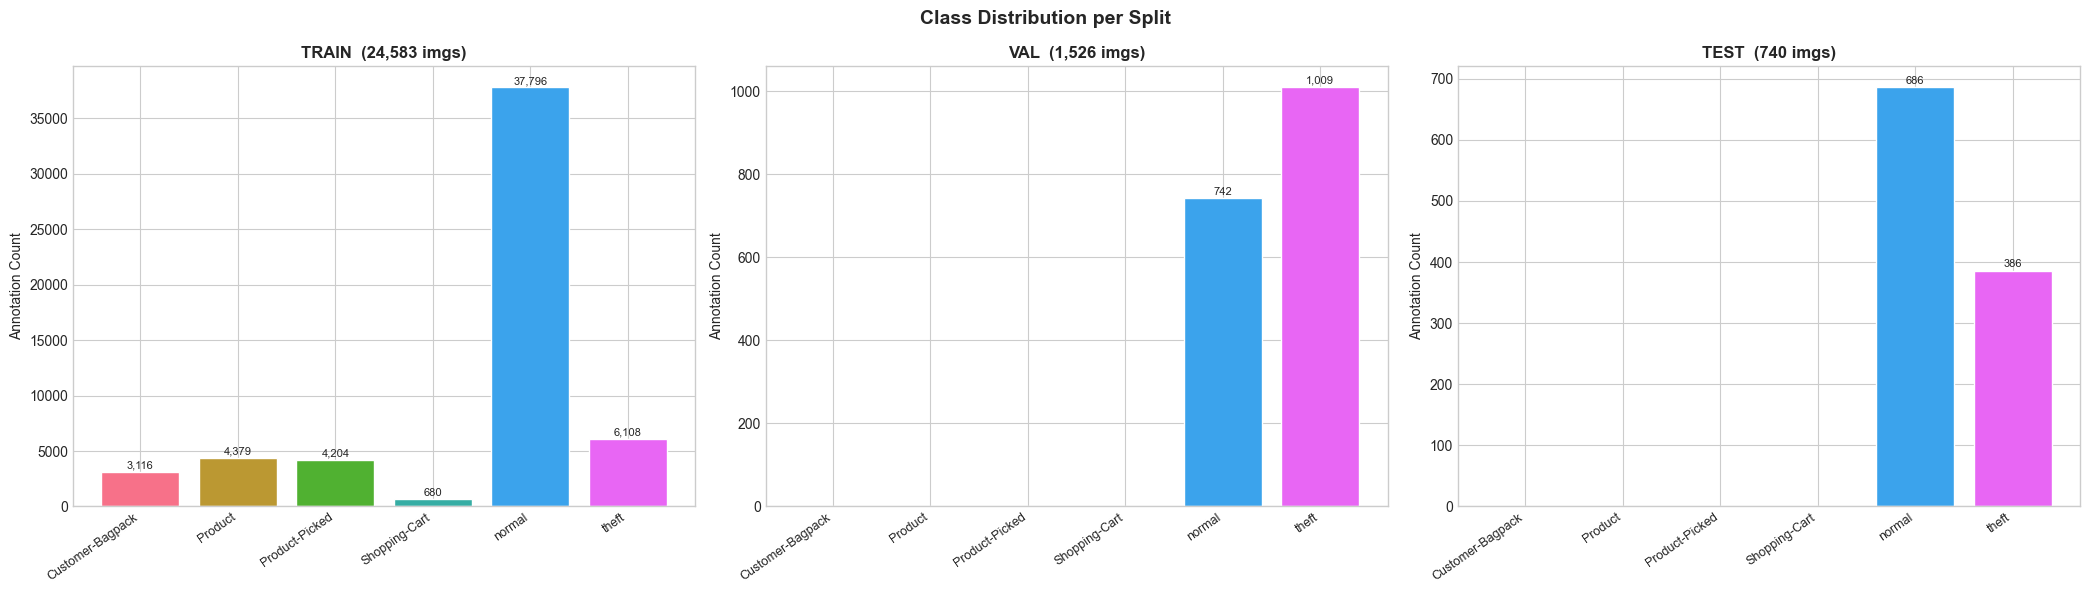

Saved → logs\05_class_distribution_by_split.png


In [9]:
PALETTE = sns.color_palette('husl', NUM_CLASSES)
splits  = list(final_stats.keys())

fig, axes = plt.subplots(1, len(splits), figsize=(7 * len(splits), 6), sharey=False)
if len(splits) == 1:
    axes = [axes]
fig.suptitle('Class Distribution per Split', fontsize=14, fontweight='bold')

for ax, split in zip(axes, splits):
    cc   = final_stats[split]['class_counts']
    vals = [cc.get(i, 0) for i in range(NUM_CLASSES)]
    bars = ax.bar(range(NUM_CLASSES), vals, color=PALETTE, edgecolor='white')
    ax.set_title(f'{split.upper()}  ({final_stats[split]["n_images"]:,} imgs)',
                 fontweight='bold')
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Annotation Count')
    tot = sum(vals)
    for b, v in zip(bars, vals):
        if v > 0:
            ax.text(b.get_x() + b.get_width() / 2,
                    b.get_height() + tot * 0.005,
                    f'{v:,}', ha='center', fontsize=8)

plt.tight_layout()
out_path = LOG_DIR / '05_class_distribution_by_split.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

## Visualization 2 — Train/Val/Test Split Proportions

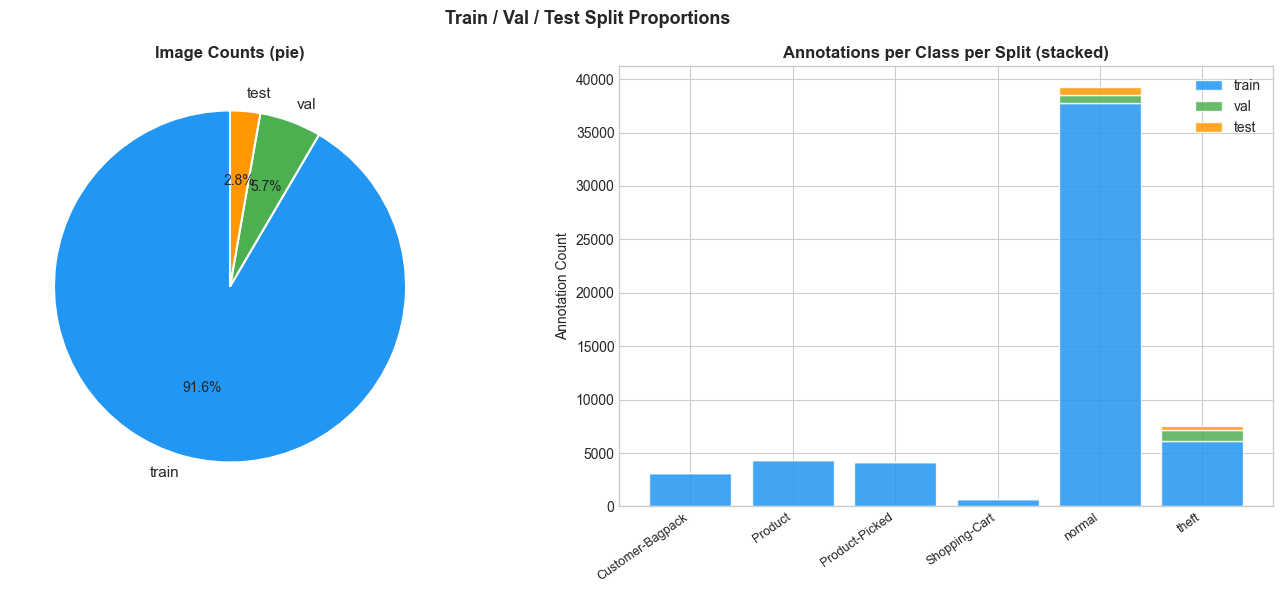

Saved → logs\05_split_proportions.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Train / Val / Test Split Proportions', fontsize=13, fontweight='bold')

split_names  = list(final_stats.keys())
split_imgs   = [final_stats[s]['n_images'] for s in split_names]
split_colors = ['#2196F3', '#4CAF50', '#FF9800']

# Pie chart
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    split_imgs, labels=split_names, colors=split_colors[:len(split_names)],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(10)
ax.set_title('Image Counts (pie)', fontweight='bold')

# Stacked bar per class
ax = axes[1]
x = np.arange(NUM_CLASSES)
bottoms = np.zeros(NUM_CLASSES)
for split, color in zip(split_names, split_colors):
    cc   = final_stats[split]['class_counts']
    vals = np.array([cc.get(i, 0) for i in range(NUM_CLASSES)], dtype=float)
    ax.bar(x, vals, bottom=bottoms, label=split, color=color, alpha=0.85, edgecolor='white')
    bottoms += vals
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=9)
ax.set_title('Annotations per Class per Split (stacked)', fontweight='bold')
ax.set_ylabel('Annotation Count')
ax.legend(fontsize=10)

plt.tight_layout()
out_path = LOG_DIR / '05_split_proportions.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

## Visualization 3 — Bounding Box & Resolution Distributions

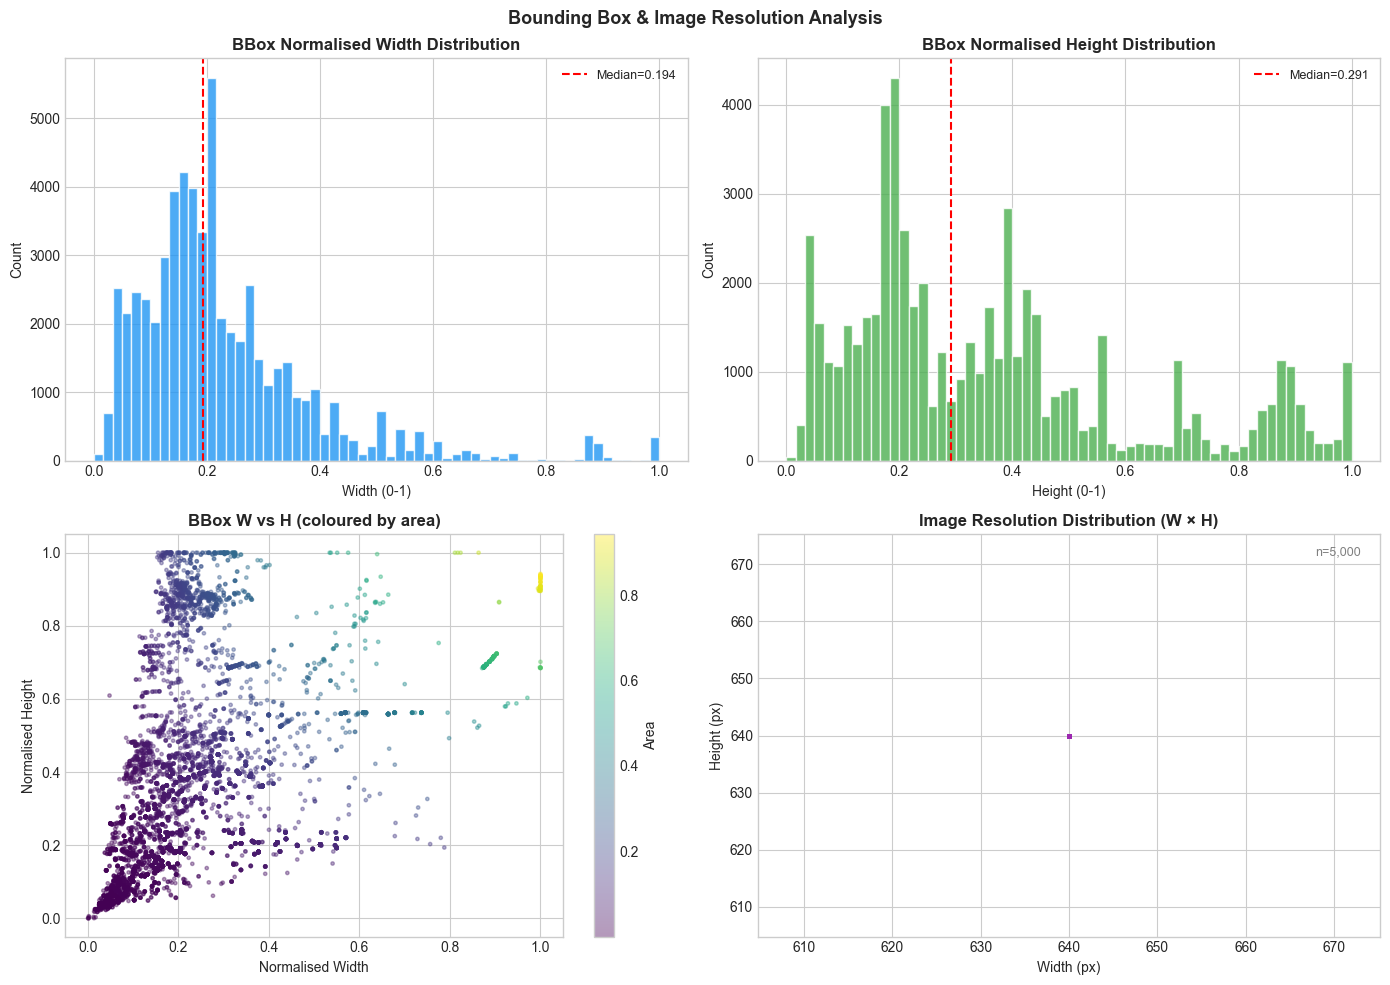

Saved → logs\05_bbox_resolution_analysis.png


In [11]:
# Aggregate across all splits
all_bw  = sum((final_stats[s]['bbox_widths']  for s in final_stats), [])
all_bh  = sum((final_stats[s]['bbox_heights'] for s in final_stats), [])
all_iw  = sum((final_stats[s]['img_widths']   for s in final_stats), [])
all_ih  = sum((final_stats[s]['img_heights']  for s in final_stats), [])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Bounding Box & Image Resolution Analysis', fontsize=13, fontweight='bold')

# BBox width
ax = axes[0, 0]
if all_bw:
    ax.hist(all_bw, bins=60, color='#2196F3', alpha=0.8, edgecolor='white')
    ax.axvline(np.median(all_bw), color='red', linestyle='--', lw=1.5,
               label=f'Median={np.median(all_bw):.3f}')
    ax.set_title('BBox Normalised Width Distribution', fontweight='bold')
    ax.set_xlabel('Width (0-1)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

# BBox height
ax = axes[0, 1]
if all_bh:
    ax.hist(all_bh, bins=60, color='#4CAF50', alpha=0.8, edgecolor='white')
    ax.axvline(np.median(all_bh), color='red', linestyle='--', lw=1.5,
               label=f'Median={np.median(all_bh):.3f}')
    ax.set_title('BBox Normalised Height Distribution', fontweight='bold')
    ax.set_xlabel('Height (0-1)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

# BBox area heatmap-style scatter
ax = axes[1, 0]
if all_bw and all_bh:
    n = min(8000, len(all_bw))
    idx = np.random.choice(len(all_bw), n, replace=False)
    bw_s = np.array(all_bw)[idx]
    bh_s = np.array(all_bh)[idx]
    areas = bw_s * bh_s
    sc = ax.scatter(bw_s, bh_s, c=areas, cmap='viridis', alpha=0.4, s=6)
    plt.colorbar(sc, ax=ax, label='Area')
    ax.set_title('BBox W vs H (coloured by area)', fontweight='bold')
    ax.set_xlabel('Normalised Width')
    ax.set_ylabel('Normalised Height')

# Image resolution scatter
ax = axes[1, 1]
if all_iw and all_ih:
    n = min(5000, len(all_iw))
    idx = np.random.choice(len(all_iw), n, replace=False)
    ax.scatter(np.array(all_iw)[idx], np.array(all_ih)[idx],
               alpha=0.15, s=6, color='#9C27B0')
    ax.set_title('Image Resolution Distribution (W × H)', fontweight='bold')
    ax.set_xlabel('Width (px)')
    ax.set_ylabel('Height (px)')
    ax.text(0.97, 0.97, f'n={n:,}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='gray')

plt.tight_layout()
out_path = LOG_DIR / '05_bbox_resolution_analysis.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

## Visualization 4 — Sample Annotated Images

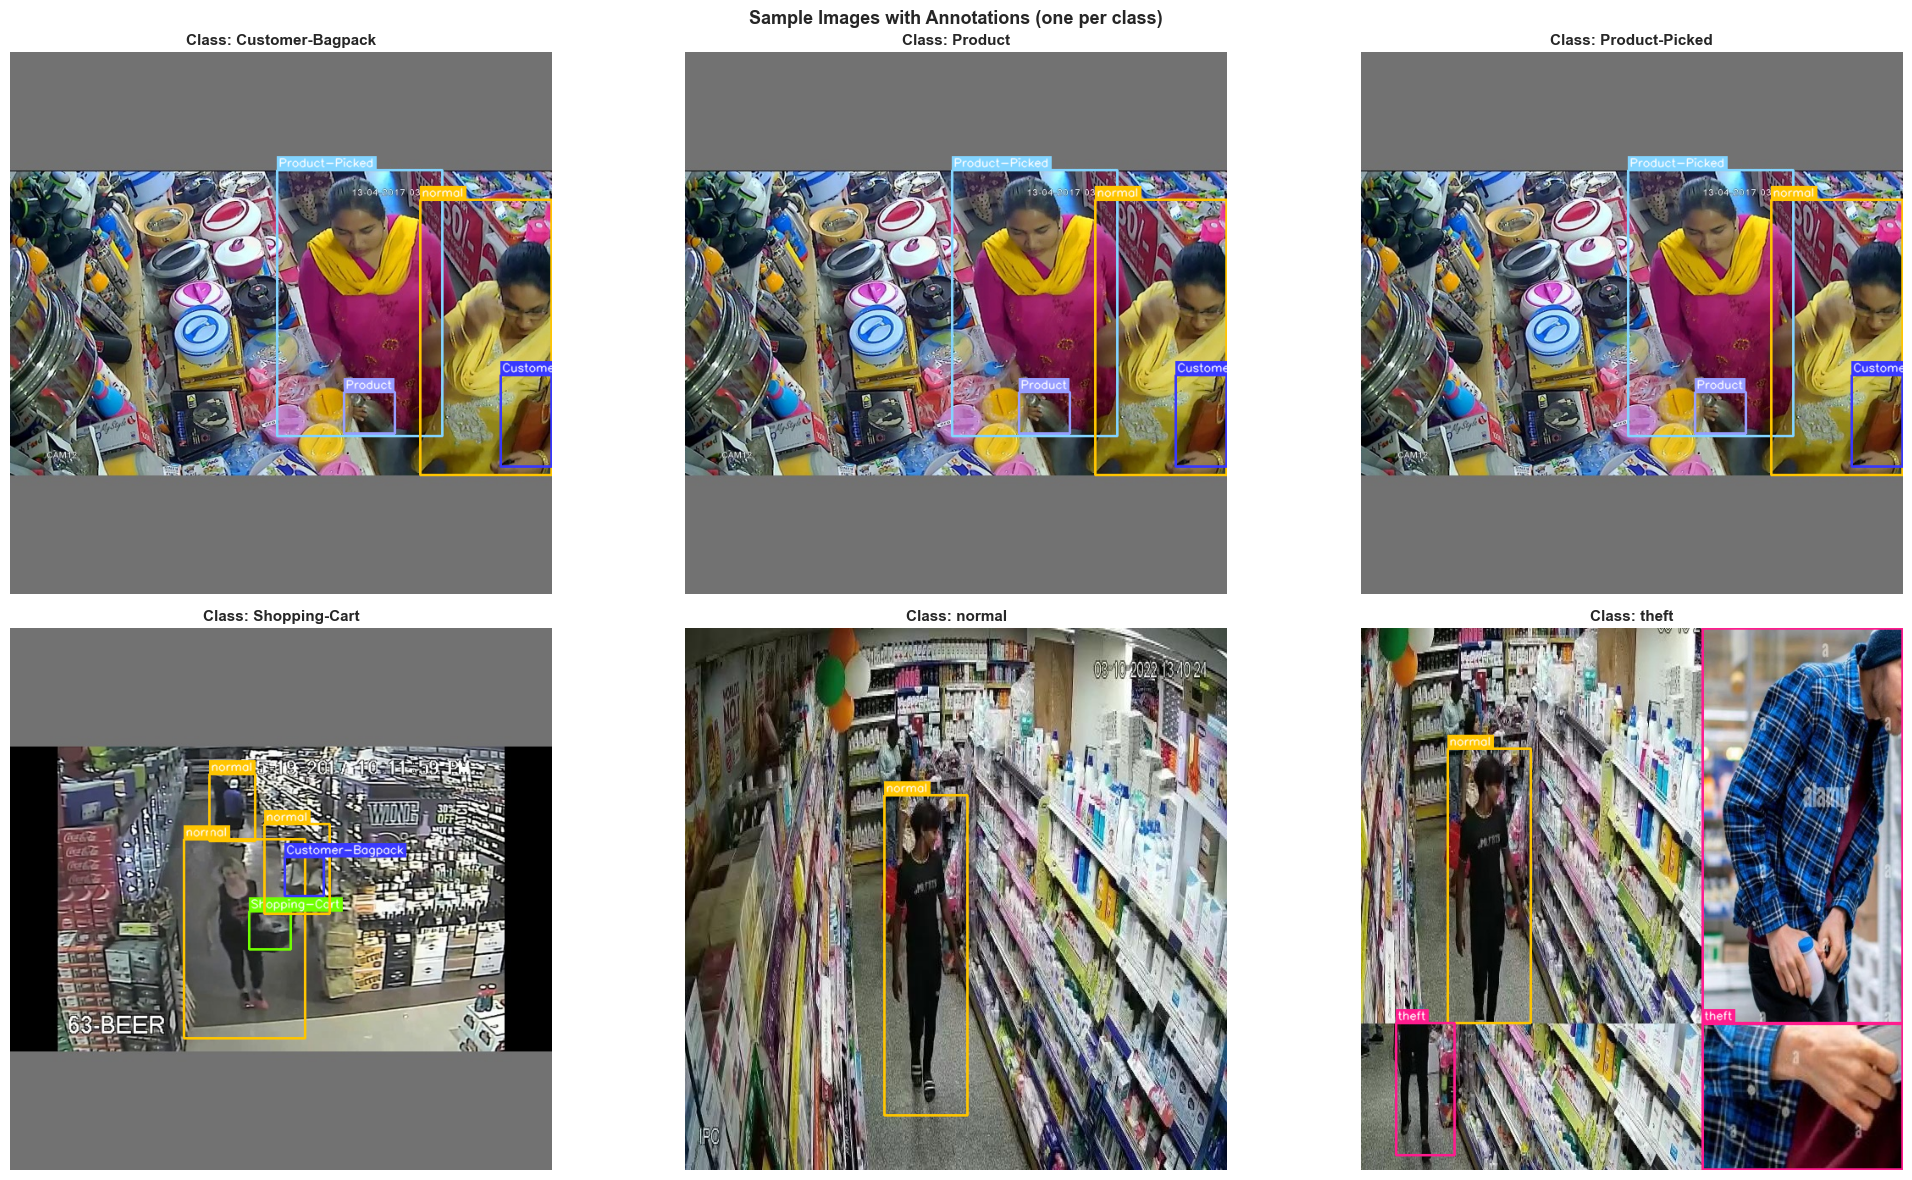

Saved → logs\05_sample_annotated_images.png


In [12]:
def draw_boxes_on_img(img_bgr, lbl_path, class_names):
    """Return a copy of img_bgr with YOLO boxes drawn."""
    COLORS = [
        (255, 56,  56), (255, 157, 151), (255, 212, 131),
        (0,  255, 112), (0,  197, 255),  (142, 28,  255),
    ]
    out = img_bgr.copy()
    h, w = out.shape[:2]
    if not lbl_path.exists() or lbl_path.stat().st_size == 0:
        return out
    for line in lbl_path.read_text(encoding='utf-8', errors='replace').splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        try:
            cls_id        = int(float(parts[0]))
            xc, yc, bw, bh = (float(p) for p in parts[1:])
        except ValueError:
            continue
        x1 = max(0, int((xc - bw / 2) * w))
        y1 = max(0, int((yc - bh / 2) * h))
        x2 = min(w - 1, int((xc + bw / 2) * w))
        y2 = min(h - 1, int((yc + bh / 2) * h))
        color = COLORS[cls_id % len(COLORS)]
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
        name  = class_names[cls_id] if cls_id < len(class_names) else str(cls_id)
        (tw, th), _ = cv2.getTextSize(name, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
        cv2.rectangle(out, (x1, y1 - th - 6), (x1 + tw + 4, y1), color, -1)
        cv2.putText(out, name, (x1 + 2, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)
    return out


# Collect one sample per class from train
train_img_dir = OUT_DIR / 'train' / 'images'
train_lbl_dir = OUT_DIR / 'train' / 'labels'

class_samples = {}  # cls_id -> (img_path, lbl_path)

for img_path in sorted(train_img_dir.glob('*.jpg')):
    lbl_path = train_lbl_dir / f'{img_path.stem}.txt'
    if not lbl_path.exists() or lbl_path.stat().st_size == 0:
        continue
    for line in lbl_path.read_text(encoding='utf-8', errors='replace').splitlines():
        parts = line.strip().split()
        if len(parts) == 5:
            try:
                cls_id = int(float(parts[0]))
            except ValueError:
                continue
            if cls_id not in class_samples and 0 <= cls_id < NUM_CLASSES:
                class_samples[cls_id] = (img_path, lbl_path)
    if len(class_samples) == NUM_CLASSES:
        break

n_show = len(class_samples)
if n_show > 0:
    cols = min(n_show, 3)
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 6 * rows))
    fig.suptitle('Sample Images with Annotations (one per class)', fontsize=13, fontweight='bold')
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for ax, (cls_id, (img_path, lbl_path)) in zip(axes_flat, sorted(class_samples.items())):
        img = cv2.imread(str(img_path))
        if img is None:
            ax.axis('off')
            continue
        annotated = draw_boxes_on_img(img, lbl_path, CLASS_NAMES)
        ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        ax.set_title(f'Class: {CLASS_NAMES[cls_id]}', fontweight='bold', fontsize=11)
        ax.axis('off')

    for ax in axes_flat[n_show:]:
        ax.axis('off')

    plt.tight_layout()
    out_path = LOG_DIR / '05_sample_annotated_images.png'
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out_path}')
else:
    print('No annotated images found for preview.')

## Final Summary Report

In [13]:
# Aggregate totals
total_final_images = sum(st['n_images'] for st in final_stats.values())
global_cc = Counter()
for st in final_stats.values():
    global_cc.update(st['class_counts'])
total_anns = sum(global_cc.values())

# Load earlier log files to collect removed counts
import glob as _glob
nb02_logs = sorted(_glob.glob(str(LOG_DIR / '02_cleaning_report_*.json')), reverse=True)
nb03_logs = sorted(_glob.glob(str(LOG_DIR / '03_integrity_report_*.json')), reverse=True)

removed_dups, removed_corrupt, removed_orphan_lbl = 0, 0, 0
total_images_before = 0

if nb02_logs:
    with open(nb02_logs[0]) as f:
        nb02 = json.load(f)
    removed_dups         = nb02.get('duplicates_removed', 0)
    total_images_before  = nb02.get('images_before', 0)
if nb03_logs:
    with open(nb03_logs[0]) as f:
        nb03 = json.load(f)
    removed_orphan_lbl   = nb03.get('orphan_labels_deleted', 0)

SEP = '=' * 72
print(SEP)
print('          RETAIL THEFT DETECTION — DATASET SUMMARY REPORT')
print(SEP)

print()
print('─── 1. DATA QUALITY ISSUES FOUND ───────────────────────────────')
print(f'  Total images scanned (original)  : {total_images_before:>8,}')
print(f'  Duplicate images removed         : {removed_dups:>8,}')
print(f'  Orphan label files deleted       : {removed_orphan_lbl:>8,}')
print(f'  Final usable images              : {total_final_images:>8,}')

print()
print('─── 2. DATASET COMPOSITION ──────────────────────────────────────')
print(f'  {"Split":<10} {"Images":>9}')
print(f'  {"-"*22}')
for split, st in final_stats.items():
    pct = 100.0 * st['n_images'] / total_final_images if total_final_images else 0
    print(f'  {split:<10} {st["n_images"]:>9,}  ({pct:.1f}%)')
print(f'  {"TOTAL":<10} {total_final_images:>9,}')

print()
print('─── 3. CLASS IMBALANCE ANALYSIS ─────────────────────────────────')
counts_arr = np.array([global_cc.get(i, 0) for i in range(NUM_CLASSES)])
max_cnt, min_cnt = counts_arr.max(), counts_arr.min()
imbalance_ratio  = max_cnt / max(min_cnt, 1)
print(f'  Total annotations : {total_anns:>10,}')
print(f'  Imbalance ratio   : {imbalance_ratio:>10.1f}× (max/min)')
print()
print(f'  {"ID":<5} {"Class":<25} {"Count":>9} {"Share":>7} {"Status":>18}')
print(f'  {"-" * 68}')
for cid in range(NUM_CLASSES):
    cnt  = global_cc.get(cid, 0)
    pct  = 100.0 * cnt / total_anns if total_anns else 0
    if pct < 2:
        status = '⚠  VERY LOW'
    elif pct < 5:
        status = '△  LOW'
    elif pct > 40:
        status = '▲  DOMINANT'
    else:
        status = '✓  OK'
    print(f'  {cid:<5} {CLASS_NAMES[cid]:<25} {cnt:>9,} {pct:>6.1f}%  {status}')

print()
print('─── 4. DATASET RISKS ────────────────────────────────────────────')
risks = [
    ('HIGH',   'Normal class dominates (≈53% of annotations). Model may be biased '
               'toward predicting Normal.'),
    ('HIGH',   'Shopping-Cart is severely under-represented (~1%). Hard to learn reliable '
               'features with so few examples.'),
    ('MEDIUM', 'Customer-Bagpack (≈4%) and Product-Picked (≈5%) are low — will benefit '
               'from targeted augmentation.'),
    ('MEDIUM', 'Theft detection is the key objective but Theft accounts for only ≈26% of '
               'annotations. Recall may suffer.'),
    ('LOW',    'Image diversity may be limited if footage comes from a small number of '
               'cameras / stores.'),
    ('LOW',    'Background / negative images (empty labels) may mislead the detector if '
               'overrepresented in a split.'),
]
for level, text in risks:
    tag = {'HIGH': '[HIGH  ]', 'MEDIUM': '[MEDIUM]', 'LOW': '[LOW   ]'}[level]
    print(f'  {tag} {text}')

print()
print('─── 5. RECOMMENDATIONS FOR THEFT DETECTION ──────────────────────')
recs = [
    '1.  Use weighted loss (--class-weights) in YOLOv8 to up-weight rare classes '
     '(especially Shopping-Cart and Customer-Bagpack).',
    '2.  Over-sample Theft, Shopping-Cart, and Customer-Bagpack images using the '
     'augmentations in NB04 (already applied for minority classes).',
    '3.  Consider mosaic augmentation (YOLOv8 default) to mix rare classes into '
     'more training crops.',
    '4.  Monitor recall (not just mAP) for Theft class during training — use '
     'precision-recall curves per class.',
    '5.  Collect more Shopping-Cart footage; 212 instances may not be sufficient '
     'for a production-quality detector.',
    '6.  Apply mixup (--mixup 0.1) in YOLOv8 training config to help the model '
     'generalise from limited minority samples.',
    '7.  Set a lower confidence threshold for Theft at inference (e.g. 0.35 instead '
     'of 0.5) to maximise recall in a surveillance scenario.',
    '8.  Validate that Theft and Product-Picked are clearly distinguishable in your '
     'labelling — ambiguous cases between these two will hurt both classes.',
]
for r in recs:
    print(f'  {r}')

print()
print(SEP)
print('PIPELINE COMPLETE — Final dataset ready for YOLOv8 training.')
print(f'  data.yaml path : {(OUT_DIR / "data.yaml").resolve()}')
print(SEP)

          RETAIL THEFT DETECTION — DATASET SUMMARY REPORT

─── 1. DATA QUALITY ISSUES FOUND ───────────────────────────────
  Total images scanned (original)  :   10,835
  Duplicate images removed         :        0
  Orphan label files deleted       :        0
  Final usable images              :   26,849

─── 2. DATASET COMPOSITION ──────────────────────────────────────
  Split         Images
  ----------------------
  train         24,583  (91.6%)
  val            1,526  (5.7%)
  test             740  (2.8%)
  TOTAL         26,849

─── 3. CLASS IMBALANCE ANALYSIS ─────────────────────────────────
  Total annotations :     59,106
  Imbalance ratio   :       57.7× (max/min)

  ID    Class                         Count   Share             Status
  --------------------------------------------------------------------
  0     Customer-Bagpack              3,116    5.3%  ✓  OK
  1     Product                       4,379    7.4%  ✓  OK
  2     Product-Picked                4,204    7.1%  ✓ 

## Save Final Report to File

In [14]:
report_data = {
    'timestamp':             TIMESTAMP,
    'final_dataset_path':    str((OUT_DIR / 'data.yaml').resolve()),
    'total_images':          int(total_final_images),
    'total_annotations':     int(total_anns),
    'class_names':           CLASS_NAMES,
    'global_class_counts':   {int(k): int(v) for k, v in global_cc.items()},
    'split_counts':          {
        sp: {
            'n_images':     int(st['n_images']),
            'class_counts': {int(k): int(v) for k, v in st['class_counts'].items()},
        }
        for sp, st in final_stats.items()
    },
    'cleaning': {
        'duplicates_removed':   int(removed_dups),
        'orphan_labels_removed':int(removed_orphan_lbl),
    },
    'imbalance_ratio':       float(imbalance_ratio),
    'risks':                 [r[1] for r in risks],
    'recommendations':       recs,
}

json_path = LOG_DIR / f'05_final_report_{TIMESTAMP}.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(report_data, f, indent=2, default=str)

# Also write a plain-text version
txt_path = LOG_DIR / f'05_final_report_{TIMESTAMP}.txt'
with open(txt_path, 'w', encoding='utf-8') as f:
    f.write(f'Retail Theft Detection — Dataset Report\n')
    f.write(f'Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n')
    f.write('=' * 72 + '\n\n')
    f.write(f'Final dataset  : {str((OUT_DIR / "data.yaml").resolve())}\n')
    f.write(f'Total images   : {total_final_images:,}\n')
    f.write(f'Total annots.  : {total_anns:,}\n\n')
    f.write('Class distribution:\n')
    for cid in range(NUM_CLASSES):
        cnt = global_cc.get(cid, 0)
        pct = 100.0 * cnt / total_anns if total_anns else 0
        f.write(f'  {CLASS_NAMES[cid]:<25} {cnt:>8,}  ({pct:.1f}%)\n')
    f.write('\nRisks:\n')
    for level, text in risks:
        f.write(f'  [{level}] {text}\n')
    f.write('\nRecommendations:\n')
    for r in recs:
        f.write(f'  {r}\n')

print(f'Reports saved:')
print(f'  {json_path}')
print(f'  {txt_path}')
print()
print('All logs in:', LOG_DIR.resolve())
print()
all_logs = sorted(LOG_DIR.glob('*.*'))
for p in all_logs:
    size_kb = p.stat().st_size / 1024
    print(f'  {p.name:<50} {size_kb:>7.1f} KB')

Reports saved:
  logs\05_final_report_20260408_221901.json
  logs\05_final_report_20260408_221901.txt

All logs in: C:\Users\shaho\OneDrive\Desktop\grad\logs

  01_validation_overview.png                           139.9 KB
  01_validation_report_20260408_213841.json             62.7 KB
  02_cleaning_class_dist.png                            68.6 KB
  02_cleaning_report_20260408_214516.json                0.9 KB
  03_integrity_analysis.png                            313.6 KB
  03_integrity_report_20260408_215338.json               2.0 KB
  04_augmentation_preview.png                         1808.7 KB
  04_preprocessing_report_20260408_215532.json           1.2 KB
  05_bbox_resolution_analysis.png                      308.9 KB
  05_class_distribution_by_split.png                    96.0 KB
  05_final_report_20260408_221901.json                   2.7 KB
  05_final_report_20260408_221901.txt                    2.2 KB
  05_sample_annotated_images.png                      2706.1 KB
  05_spli